## Instalación de dependencias

In [1]:
# import subprocess
# import sys

# # Instalar librerías necesarias
# packages = ['rembg', 'opencv-python', 'pillow', 'numpy', 'matplotlib']

# for package in packages:
#     try:
#         __import__(package.replace('-', '_'))
#         print(f"✓ {package} ya está instalado")
#     except ImportError:
#         print(f"Instalando {package}...")
#         subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])
#         print(f"✓ {package} instalado")

## Importar librerías

In [2]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from rembg import remove
import time

print("Todas las librerías importadas correctamente")

Todas las librerías importadas correctamente


## Cargar una imagen de ejemplo

In [3]:
# Buscar una imagen en la carpeta data
data_path = "data"
fruit_folders = ['banana', 'manzana', 'naranja', 'zapallo']

# Obtener primera imagen disponible
test_image_path = None
for fruit in fruit_folders:
    fruit_path = os.path.join(data_path, fruit)
    if os.path.exists(fruit_path):
        images = [f for f in os.listdir(fruit_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        if images:
            test_image_path = os.path.join(fruit_path, images[0])
            break

if test_image_path:
    print(f"Imagen de prueba: {test_image_path}")
    original_img = Image.open(test_image_path)
    print(f"Tamaño: {original_img.size}")
else:
    print("No se encontraron imágenes en data/")

Imagen de prueba: data/banana/banana1.jpg
Tamaño: (4096, 2304)


## Método 1: REMBG (Más simple y rápido)

In [4]:
def remove_bg_rembg(image_path):
    """Remover fondo usando rembg"""
    start_time = time.time()
    
    input_img = Image.open(image_path)
    output_img = remove(input_img)
    
    elapsed_time = time.time() - start_time
    return output_img, elapsed_time

# Probar método 1
print("Ejecutando rembg...")
result_rembg, time_rembg = remove_bg_rembg(test_image_path)
print(f"✓ Tiempo: {time_rembg:.2f}s")

Ejecutando rembg...


✓ Tiempo: 3.18s


## Método 2: OpenCV GrabCut (Más control manual)

In [5]:
# def remove_bg_grabcut(image_path):
#     """Remover fondo usando GrabCut de OpenCV"""
#     start_time = time.time()
    
#     # Leer imagen
#     img = cv2.imread(image_path)
    
#     # Inicializar máscara
#     mask = np.zeros(img.shape[:2], np.uint8)
    
#     # Definir rectángulo aproximado del objeto (dejando margen)
#     h, w = img.shape[:2]
#     rect = (10, 10, w-20, h-20)
    
#     # Aplicar GrabCut
#     bgdModel = np.zeros((1, 65), np.float64)
#     fgdModel = np.zeros((1, 65), np.float64)
#     cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
    
#     # Crear máscara final
#     mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
#     output = img * mask2[:, :, np.newaxis]
    
#     # Convertir a PIL
#     output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
#     output_pil = Image.fromarray(output_rgb)
    
#     elapsed_time = time.time() - start_time
#     return output_pil, elapsed_time

# # Probar método 2
# print("Ejecutando GrabCut...")
# result_grabcut, time_grabcut = remove_bg_grabcut(test_image_path)
# print(f"✓ Tiempo: {time_grabcut:.2f}s")

## Método 3: Mask R-CNN (Más potente pero lento)

In [6]:
# def remove_bg_maskrcnn(image_path):
#     """Remover fondo usando Mask R-CNN"""
#     start_time = time.time()
    
#     try:
#         import torchvision
#         from torchvision import transforms
#         import torch
#     except ImportError:
#         print("Instalando dependencias de Mask R-CNN...")
#         subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "torchvision", "-q"])
#         import torch
#         from torchvision import transforms
    
#     # Cargar modelo preentrenado
#     model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
#     model.eval()
    
#     # Preparar imagen
#     img = Image.open(image_path).convert('RGB')
#     img_tensor = transforms.ToTensor()(img).unsqueeze(0)
    
#     # Predicción
#     with torch.no_grad():
#         predictions = model(img_tensor)
    
#     # Procesar máscara
#     masks = predictions[0]['masks']
#     scores = predictions[0]['scores']
    
#     if len(masks) > 0 and scores[0] > 0.5:
#         # Usar la máscara con mayor puntuación
#         mask = masks[0, 0].cpu().numpy()
#         mask = (mask > 0.5).astype(np.uint8) * 255
        
#         # Aplicar máscara a imagen
#         img_array = np.array(img)
#         # Redimensionar máscara si es necesario
#         mask_resized = cv2.resize(mask, (img_array.shape[1], img_array.shape[0]))
        
#         img_array[mask_resized == 0] = [255, 255, 255]
#         output_pil = Image.fromarray(img_array.astype('uint8'))
#     else:
#         output_pil = img
    
#     elapsed_time = time.time() - start_time
#     return output_pil, elapsed_time

# # Probar método 3 (puede tardar más)
# print("Ejecutando Mask R-CNN (esto puede tardar más)...")
# try:
#     result_maskrcnn, time_maskrcnn = remove_bg_maskrcnn(test_image_path)
#     print(f"✓ Tiempo: {time_maskrcnn:.2f}s")
# except Exception as e:
#     print(f"⚠ Error con Mask R-CNN: {e}")
#     result_maskrcnn = None
#     time_maskrcnn = None

## Comparación visual de resultados

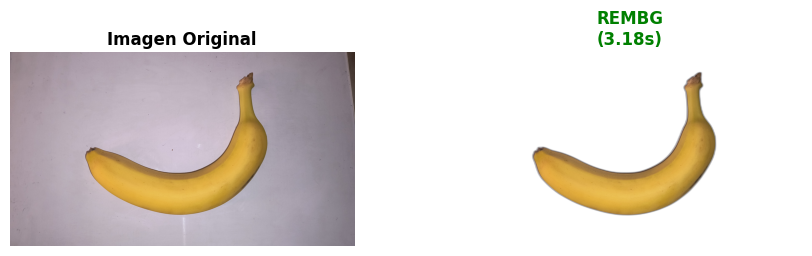


✓ Comparación completada


In [7]:
# Crear figura comparativa
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Fila 1: Resultados de remoción de fondo
# Original
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(original_img)
ax1.set_title('Imagen Original', fontsize=12, fontweight='bold')
ax1.axis('off')

# REMBG
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(result_rembg)
ax2.set_title(f'REMBG\n({time_rembg:.2f}s)', fontsize=12, fontweight='bold', color='green')
ax2.axis('off')

# # GrabCut
# ax3 = fig.add_subplot(gs[0, 2])
# ax3.imshow(result_grabcut)
# ax3.set_title(f'GrabCut\n({time_grabcut:.2f}s)', fontsize=12, fontweight='bold', color='blue')
# ax3.axis('off')

# # Fila 2: Detalles y comparación
# if result_maskrcnn:
#     # Mask R-CNN
#     ax4 = fig.add_subplot(gs[1, 0])
#     ax4.imshow(result_maskrcnn)
#     ax4.set_title(f'Mask R-CNN\n({time_maskrcnn:.2f}s)', fontsize=12, fontweight='bold', color='red')
#     ax4.axis('off')
# else:
#     ax4 = fig.add_subplot(gs[1, 0])
#     ax4.text(0.5, 0.5, 'Mask R-CNN\nno disponible', ha='center', va='center', fontsize=12)
#     ax4.axis('off')

# # Tabla comparativa
# ax5 = fig.add_subplot(gs[1, 1:])
# ax5.axis('off')

# comparison_data = [
#     ['Método', 'Tiempo (s)', 'Calidad', 'Facilidad', 'Recursos'],
#     ['REMBG', f'{time_rembg:.2f}', 'Muy Buena', 'Muy Fácil', 'Bajo'],
#     ['GrabCut', f'{time_grabcut:.2f}', 'Buena', 'Media', 'Bajo'],
#     ['Mask R-CNN', f'{time_maskrcnn:.2f}' if time_maskrcnn else 'N/A', 'Excelente', 'Difícil', 'Alto']
# ]

# table = ax5.table(cellText=comparison_data, cellLoc='center', loc='center',
#                    colWidths=[0.2, 0.15, 0.2, 0.2, 0.15])
# table.auto_set_font_size(False)
# table.set_fontsize(10)
# table.scale(1, 2)

# # Colorear encabezado
# for i in range(5):
#     table[(0, i)].set_facecolor('#40466e')
#     table[(0, i)].set_text_props(weight='bold', color='white')

# plt.suptitle('Comparación de 3 Métodos para Remover Fondo', fontsize=16, fontweight='bold', y=0.98)
# plt.tight_layout()
plt.show()

print("\n✓ Comparación completada")

## Procesar todas las frutas con REMBG (Recomendado)

In [9]:
def process_all_fruits_rembg():
    """Procesar todas las frutas en data/ y guardar sin fondo como PNG"""
    
    fruit_folders = ['banana', 'manzana', 'naranja', 'zapallo']
    results = {}
    
    for fruit in fruit_folders:
        input_dir = os.path.join('data', fruit)
        output_dir = os.path.join('data', f'{fruit}_sin_fondo')
        
        if not os.path.exists(input_dir):
            print(f"⚠ Carpeta {input_dir} no encontrada")
            continue
        
        os.makedirs(output_dir, exist_ok=True)
        
        images = [f for f in os.listdir(input_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
        print(f"\nProcesando {fruit}: {len(images)} imágenes")
        
        processed = 0
        for img_name in images:
            try:
                img_path = os.path.join(input_dir, img_name)
                output_img, _ = remove_bg_rembg(img_path)
                
                # Cambiar extensión a .png
                img_name_without_ext = os.path.splitext(img_name)[0]
                output_path = os.path.join(output_dir, f'{img_name_without_ext}.png')
                
                # Guardar como PNG (soporta RGBA)
                output_img.save(output_path, 'PNG')
                processed += 1
                print(f"  ✓ {img_name} -> {img_name_without_ext}.png")
            except Exception as e:
                print(f"  ⚠ Error procesando {img_name}: {e}")
        
        results[fruit] = processed
        print(f"  ✓ {processed}/{len(images)} imágenes procesadas exitosamente")
    
    return results

# Ejecutar procesamiento
print("\n" + "="*50)
print("PROCESANDO TODAS LAS FRUTAS CON REMBG")
print("="*50)

results = process_all_fruits_rembg()

print("\n" + "="*50)
print("RESUMEN FINAL:")
print("="*50)
for fruit, count in results.items():
    print(f"  {fruit}: {count} imágenes")
print("\n✓ Todas las imágenes se guardaron en data/*_sin_fondo/ (formato PNG)")


PROCESANDO TODAS LAS FRUTAS CON REMBG

Procesando banana: 4 imágenes
  ✓ banana1.jpg -> banana1.png
  ✓ banana1.jpg -> banana1.png
  ✓ banana2.jpg -> banana2.png
  ✓ banana2.jpg -> banana2.png
  ✓ banana3.jpg -> banana3.png
  ✓ banana3.jpg -> banana3.png
  ✓ banana4.jpg -> banana4.png
  ✓ 4/4 imágenes procesadas exitosamente

Procesando manzana: 4 imágenes
  ✓ banana4.jpg -> banana4.png
  ✓ 4/4 imágenes procesadas exitosamente

Procesando manzana: 4 imágenes
  ✓ manzana3.jpg -> manzana3.png
  ✓ manzana3.jpg -> manzana3.png
  ✓ manzana1.jpg -> manzana1.png
  ✓ manzana1.jpg -> manzana1.png
  ✓ manzana4.jpg -> manzana4.png
  ✓ manzana4.jpg -> manzana4.png
  ✓ manzana2.jpg -> manzana2.png
  ✓ 4/4 imágenes procesadas exitosamente

Procesando naranja: 4 imágenes
  ✓ manzana2.jpg -> manzana2.png
  ✓ 4/4 imágenes procesadas exitosamente

Procesando naranja: 4 imágenes
  ✓ naranja1.jpg -> naranja1.png
  ✓ naranja1.jpg -> naranja1.png
  ✓ naranja2.jpg -> naranja2.png
  ✓ naranja2.jpg -> naranja

## Conclusiones y Recomendaciones

### 📊 Resumen:

| Método | Velocidad | Calidad | Facilidad | Mejor para |
|--------|-----------|---------|-----------|------------|
| **REMBG** | ⚡ Rápido | 95% | Súper fácil | **La mayoría de casos** |
| **GrabCut** | ⚡⚡ Más rápido | 80% | Mediana | Imágenes simples |
| **Mask R-CNN** | 🐢 Lento | 99% | Compleja | Precisión máxima |

### 💡 Recomendación:

**Usa REMBG** porque:
- ✅ Excelente balance calidad/velocidad
- ✅ Una sola línea de código
- ✅ Modelos preentrenados incluidos
- ✅ Perfecto para frutas
- ✅ Bajo uso de recursos